# Lesion geometry: CBIS-DDSM mass masks

`01_eda` describes the data image by image. This notebook describes it lesion by lesion, because the lesion is the unit that the project's classifiers and its localiser work on. It reads the lesion masks of the dataset [1] and answers the questions that fixed the design of the localisation stage.

1. How do the lesions divide among the partitions, and how many mammograms hold more than one?
2. Are the masks clean enough that the bounding box of the foreground is the box of the lesion?
3. How large is a mass, in pixels and as a share of its mammogram?
4. At what input size does a segmentation network [2] still see the smallest masses?
5. Does mapping a box to the network's input and back preserve it?
6. How much of a crop is lost at the image border as the margin around the box grows?

**Use of the test partition.** The geometry is computed for every lesion, those of the test partition included, because the pipeline needs it for every lesion. It is measured from masks and image headers; nothing here is computed from a label or from a model's output. The label and the patient of each lesion are carried into the cached table from the case files, as columns. Beyond that, the test partition appears only in counts: those in the pipeline's record, ratios of them, and the label-free counts of patients, mammograms and lesions over both case files in section 1.2. The comparison in section 7.2 uses the training and validation partitions only.

**The cached tables.** Sections 3 and 4 hold the code that builds `artifacts/lesion_geometry.csv`, which the pipeline reads, and `artifacts/lesion_bbox_lcc.csv`. Both take a pass over all the masks, so the notebook loads the committed tables. Setting `FORCE` (section 3) or `FORCE_LCC` (section 4) to `True` rebuilds them into `outputs/_scratch/lesion_geometry/` instead; nothing is written to `artifacts/`.

**Numbers.** Figures are printed by the code cells and are not repeated in the text, so the text cannot disagree with the data.

| section | purpose |
| :--- | :--- |
| 0. Setup | seeds, paths, imports |
| 1. Lesions and partition | lesions, images and patients per partition; mammograms with several lesions |
| 2. Masks and mammograms | every lesion resolves to a mask and to its mammogram |
| 3. Geometry of every lesion | the box of each mask in mammogram coordinates, and what goes into the cached table |
| 4. Stray components in the masks | whether specks in a mask move its bounding box |
| 5. Lesion size | size in pixels and as a share of the mammogram; foreground share and the loss |
| 6. Input size for the localiser | how large the masses remain under each candidate input |
| 7. Boxes on the canvas | a box mapped to the canvas and back; the pipeline's canvas-derived boxes against the full-resolution ones |
| 8. Crop margin | clamping at the image border as the margin grows |
| 9. Summary | the measurements, and what they fixed in the design |

**References**

[1] R. S. Lee, F. Gimenez, A. Hoogi, K. K. Miyake, M. Gorovoy and D. L. Rubin, "A curated mammography data set for use in computer-aided detection and diagnosis research," *Scientific Data*, vol. 4, 170177, 2017. doi: 10.1038/sdata.2017.177

[2] O. Ronneberger, P. Fischer and T. Brox, "U-Net: convolutional networks for biomedical image segmentation," in *Medical Image Computing and Computer-Assisted Intervention (MICCAI)*, LNCS vol. 9351, pp. 234–241, 2015. doi: 10.1007/978-3-319-24574-4_28

## 0. Setup

Seeds, paths and constants come from `src/config.py`. Nothing is set by hand in this notebook.

In [1]:
import json
import os
import random
import sys
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydicom
import seaborn as sns
from IPython.display import Markdown, display
from scipy import ndimage

from src import config
from src import data_loader as dl
from src.localise import Letterbox, box_iou, expand_box

SEED = config.SEED
random.seed(SEED)
np.random.seed(SEED)

FIG_DIR = config.FIGURES_DIR / "lesion"
ARTIFACTS = PROJECT_ROOT / "artifacts"
GEOM_CSV = ARTIFACTS / "lesion_geometry.csv"
LCC_CSV = ARTIFACTS / "lesion_bbox_lcc.csv"
SCRATCH = config.OUTPUTS_DIR / "_scratch" / "lesion_geometry"
LESION_COL = "cropped image file path"
PARTS = ("train", "val", "test")
CANVAS_H, CANVAS_W = config.LOC_INPUT_H, config.LOC_INPUT_W
N_WORKERS = 10

FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 150, "savefig.bbox": "tight"})

print(f"numpy {np.__version__} | pandas {pd.__version__} | pydicom {pydicom.__version__}")
print(f"Localiser canvas {CANVAS_H} x {CANVAS_W} | crop margin {config.CROP_MARGIN_FRAC}")

numpy 1.26.4 | pandas 3.0.2 | pydicom 3.0.2
Localiser canvas 1024 x 576 | crop margin 0.2


## 1. Lesions and partition

### 1.1 Lesions per partition

The case files hold one row per abnormality, so at lesion level nothing is merged: every row is a lesion with its own label, its own mask and its own cropped patch. Patients are assigned to partitions once, and the lesion-level frames follow the same assignment as the image-level ones in `01_eda`, so a patient's lesions and images always fall in the same partition.

The test frame is not loaded. `split_frames` refuses it outside the final evaluation, and its size is read from `outputs/results/data_flow.json`, the record the pipeline wrote when it ran. The cell checks the training and validation frames against that record.

In [2]:
frames = dl.split_frames("crop")
les_train, les_val = frames["train"], frames["val"]
PARTITIONS = {"Train": les_train, "Val": les_val}

with open(config.RESULTS_DIR / "data_flow.json") as f:
    recorded = json.load(f)["partitions"]

for name, df in (("train", les_train), ("val", les_val)):
    record = recorded[name]
    assert len(df) == record["lesions"], f"{name}: lesion count differs from the record"
    assert df["patient_id"].nunique() == record["patients"], f"{name}: patient count differs"
    assert int(df["label"].sum()) == record["lesions_malignant"], f"{name}: label count differs"
    assert df["lesion_id"].is_unique, f"{name}: a lesion appears twice"

partition_table = pd.DataFrame(recorded).T[["patients", "images", "lesions", "lesions_malignant"]]
partition_table["malignant share of lesions"] = (
    partition_table["lesions_malignant"] / partition_table["lesions"]
)
print("Partition, from the pipeline's record (train and validation verified above):")
display(partition_table.round(3))

Partition, from the pipeline's record (train and validation verified above):


,patients,images,lesions,lesions_malignant,malignant share of lesions
train,644,1146,1210,559,0.462
val,129,225,243,112,0.461
test,119,221,243,113,0.465


### 1.2 Mammograms with several lesions

There are more lesions than mammograms, because some mammograms show more than one mass. The first table counts mammograms by the number of lesions they hold, over both case files and without using a label. The second gives, for each partition, the mammograms that hold more than one lesion.

This is why the project keeps two kinds of training data. A classifier is trained on one crop per lesion. Six of the seven members of the localiser ensemble are trained on a store that holds one target per mammogram, in which all the lesion masks of that mammogram are merged, so that a second mass on the image is not treated as background. The seventh is trained on per-lesion targets.

In [3]:
pool = dl._pool_frames(
    dl._prepare_frame(config.TRAIN_CSV, LESION_COL),
    dl._prepare_frame(config.TEST_CSV, LESION_COL),
    LESION_COL,
)
assert len(pool) == sum(recorded[part]["lesions"] for part in PARTS), "Lesion pool differs in size"
assert pool["lesion_id"].is_unique, "Two rows share a lesion id"

print(f"Patients: {pool['patient_id'].nunique():,}")
print(f"Mammograms: {pool['image_id'].nunique():,}")
print(f"Lesions: {len(pool):,}")

per_image = pool.groupby("image_id").size()
by_count = per_image.value_counts().sort_index().rename_axis("lesions on the mammogram")
display(by_count.to_frame("mammograms"))

rows = []
for name, df in PARTITIONS.items():
    lesions_on = df.groupby("image_id").size()
    rows.append(
        {
            "partition": name,
            "mammograms": len(lesions_on),
            "lesions": len(df),
            "mammograms with several lesions": int((lesions_on > 1).sum()),
        }
    )
several = pd.DataFrame(rows).set_index("partition")
several["share of mammograms"] = several["mammograms with several lesions"] / several["mammograms"]
display(several.round(3))

Patients: 892
Mammograms: 1,592
Lesions: 1,696


,mammograms
lesions on the mammogram,
1,1521
2,48
3,17
4,3
5,2
6,1


,mammograms,lesions,mammograms with several lesions,share of mammograms
partition,,,,
Train,1146,1210,46,0.040
Val,225,243,12,0.053


## 2. Masks and mammograms

Every lesion has to resolve to two files: its mask and the mammogram it was drawn on. Both are found through the loader's own lookups, the ones the training code uses, so this cell also tests them. `01_eda` (section 3.4) shows that the mask lookup returns the 8-bit mask, and not the cropped patch, for every lesion.

Only headers are read from the mammograms in this notebook. No mammogram pixels are decoded.

In [4]:
mask_lookup = dl._build_combined_roi_lookup(config.TRAIN_ROI_DIR, config.TEST_ROI_DIR, pick="mask")
full_lookup = dl._build_combined_lookup(config.TRAIN_IMG_DIR, config.TEST_IMG_DIR)
full_lookup = {Path(key).parts[0]: path for key, path in full_lookup.items()}

no_mask = [lesion for lesion in pool["lesion_id"] if lesion not in mask_lookup]
no_image = [image for image in pool["image_id"] if image not in full_lookup]
print(f"Mask lookup: {len(mask_lookup):,} lesions | mammogram lookup: {len(full_lookup):,} images")
print(f"Lesions with no mask: {len(no_mask)} | lesions with no mammogram: {len(no_image)}")
assert not no_mask, f"Unresolved masks, for example {no_mask[:3]}"
assert not no_image, f"Unresolved mammograms, for example {no_image[:3]}"

Mask lookup: 1,696 lesions | mammogram lookup: 1,592 images
Lesions with no mask: 0 | lesions with no mammogram: 0


## 3. Geometry of every lesion

One pass over all the masks. Each mask is thresholded at half its maximum and the box is the bounding box of the foreground. This is the rule `data_loader` applies when it crops from a mask, the route that serves the development progression, the architecture comparison and four of the five fusion stores. The ladder's conditions, and the fusion model that uses the localiser's boxes, take their boxes from a box provider instead, whose ground-truth boxes are derived on the localiser's canvas; section 7.2 compares the two. For each lesion the pass records:

- the bounding box of the foreground, in mammogram coordinates. A mask that is stored at a different size from its mammogram is rescaled, axis by axis (`01_eda`, section 12.3);
- the foreground as a share of the mask and of the box, the box's aspect ratio and its centre;
- the number of connected components and the share of the foreground in the largest;
- for a set of crop margins, whether the expanded box crosses the image border and how much of the mammogram the crop covers.

The columns ending in `_at_unet` project the box onto a 512 x 512 input. They belong to the cached table and are not used below; section 6 compares input sizes properly.

The table stores each box as a centre and a size. The last lines of the cell rebuild its corners, which the later sections use.

In [5]:
FORCE = False
UNET_INPUT = 512
CACHED_MARGINS = (0.0, 0.10, 0.20, 0.40, 0.80, 1.00)


def read_mask(lesion_id: str) -> tuple[np.ndarray, bool]:
    ds = pydicom.dcmread(mask_lookup[lesion_id], force=True)
    mask = ds.pixel_array
    inverted = getattr(ds, "PhotometricInterpretation", "MONOCHROME2") == "MONOCHROME1"
    if inverted:
        mask = mask.max() - mask
    threshold = mask.max() * 0.5 if mask.max() > 0 else 0
    return mask > threshold, inverted


def foreground_box(binary: np.ndarray) -> tuple[int, int, int, int]:
    ys = np.flatnonzero(np.any(binary, axis=1))
    xs = np.flatnonzero(np.any(binary, axis=0))
    return int(ys[0]), int(ys[-1]), int(xs[0]), int(xs[-1])


def margin_columns(box: tuple[int, int, int, int], shape: tuple[int, int]) -> dict:
    by0, by1, bx0, bx1 = box
    img_h, img_w = shape
    bh, bw = by1 - by0 + 1, bx1 - bx0 + 1
    out = {}
    for margin in CACHED_MARGINS:
        my, mx = int(bh * margin), int(bw * margin)
        ey0, ey1 = by0 - my, by1 + 1 + my
        ex0, ex1 = bx0 - mx, bx1 + 1 + mx
        wanted = (ey1 - ey0) * (ex1 - ex0)
        kept = (min(img_h, ey1) - max(0, ey0)) * (min(img_w, ex1) - max(0, ex0))
        tag = f"m{int(margin * 100):03d}"
        out[f"{tag}_clamped"] = kept < wanted
        out[f"{tag}_kept_frac"] = kept / wanted
        out[f"{tag}_img_frac"] = kept / (img_h * img_w)
    return out


def mask_geometry(lesion_id: str, image_id: str, label: int, patient_id: str) -> dict:
    rec = {"lesion_id": lesion_id, "image_id": image_id, "label": int(label)}
    rec.update(patient_id=patient_id, status="ok")
    try:
        header = pydicom.dcmread(full_lookup[image_id], stop_before_pixels=True, force=True)
        img_h, img_w = int(header.Rows), int(header.Columns)
        binary, rec["mask_mono1"] = read_mask(lesion_id)
        n_fg = int(binary.sum())
        if n_fg == 0:
            rec["status"] = "empty_mask"
            return rec

        mask_h, mask_w = binary.shape
        y0, y1, x0, x1 = foreground_box(binary)
        labelled, n_comp = ndimage.label(binary)
        largest = int(np.bincount(labelled.ravel())[1:].max()) if n_comp else 0

        sy, sx = img_h / mask_h, img_w / mask_w
        by0, by1 = int(y0 * sy), int(y1 * sy)
        bx0, bx1 = int(x0 * sx), int(x1 * sx)
        bh, bw = by1 - by0 + 1, bx1 - bx0 + 1

        rec.update(img_h=img_h, img_w=img_w, mask_h=mask_h, mask_w=mask_w)
        rec.update(scale_y=sy, scale_x=sx, grid_exact=(mask_h == img_h and mask_w == img_w))
        rec.update(box_h=bh, box_w=bw, box_area=bh * bw, img_area=img_h * img_w)
        rec.update(box_area_frac=(bh * bw) / (img_h * img_w))
        rec.update(fg_px=n_fg, fg_frac_of_mask=n_fg / (mask_h * mask_w))
        rec.update(fg_frac_of_box=n_fg * sy * sx / (bh * bw), aspect=bh / bw)
        rec.update(cy_norm=((by0 + by1) / 2) / img_h, cx_norm=((bx0 + bx1) / 2) / img_w)
        rec.update(n_components=int(n_comp), largest_comp_frac=largest / n_fg)
        rec.update(box_h_at_unet=bh / img_h * UNET_INPUT, box_w_at_unet=bw / img_w * UNET_INPUT)
        rec.update(margin_columns((by0, by1, bx0, bx1), (img_h, img_w)))
    except Exception as exc:
        rec["status"] = f"error: {type(exc).__name__}: {exc}"
    return rec


if GEOM_CSV.exists() and not FORCE:
    geom = pd.read_csv(GEOM_CSV)
    print(f"Loaded {GEOM_CSV.relative_to(PROJECT_ROOT)}: {len(geom):,} lesions")
else:
    tasks = pool[["lesion_id", "image_id", "label", "patient_id"]].itertuples(index=False)
    with ThreadPoolExecutor(max_workers=N_WORKERS) as workers:
        geom = pd.DataFrame(workers.map(lambda task: mask_geometry(*task), tasks))
    SCRATCH.mkdir(parents=True, exist_ok=True)
    geom.to_csv(SCRATCH / GEOM_CSV.name, index=False)
    print(f"Written {(SCRATCH / GEOM_CSV.name).relative_to(PROJECT_ROOT)}: {len(geom):,} lesions")

assert set(geom["lesion_id"]) == set(pool["lesion_id"]), "The table and the case files differ"
assert (geom["status"] == "ok").all(), "Some masks could not be measured"

centre_y, centre_x = geom["cy_norm"] * geom["img_h"], geom["cx_norm"] * geom["img_w"]
geom["box_y0"] = (centre_y - (geom["box_h"] - 1) / 2).round().astype(int)
geom["box_x0"] = (centre_x - (geom["box_w"] - 1) / 2).round().astype(int)
geom["box_y1"] = geom["box_y0"] + geom["box_h"] - 1
geom["box_x1"] = geom["box_x0"] + geom["box_w"] - 1

partition_of = {lesion: name for name, df in PARTITIONS.items() for lesion in df["lesion_id"]}
geom["partition"] = geom["lesion_id"].map(partition_of).fillna("Test")
print(geom["partition"].value_counts().rename_axis(None).to_string())

Loaded artifacts/lesion_geometry.csv: 1,696 lesions
Train    1210
Test      243
Val       243


## 4. Stray components in the masks

The ground-truth box is the bounding box of everything above the threshold. If a mask held a stray speck far from the lesion, that box would stretch to include it and the crop would be wrong. The check compares, for every lesion, the box of all the foreground with the box of the largest connected component alone. It reports how many components the masks have, how much of the foreground the largest one holds, and the overlap (IoU) of the two boxes.

If the two boxes agree, the simple rule is safe and the ground truth needs no clean-up. The same finding supports the rule applied to the localiser's output, which keeps one component per prediction.

In [6]:
FORCE_LCC = False


def component_check(lesion_id: str) -> dict:
    binary, _ = read_mask(lesion_id)
    if not binary.any():
        return {"lesion_id": lesion_id, "status": "empty"}
    labelled, n_comp = ndimage.label(binary)
    sizes = np.bincount(labelled.ravel())[1:]
    largest = labelled == (int(sizes.argmax()) + 1)

    ay0, ay1, ax0, ax1 = foreground_box(binary)
    ly0, ly1, lx0, lx1 = foreground_box(largest)
    overlap_h = max(0, min(ay1, ly1) - max(ay0, ly0) + 1)
    overlap_w = max(0, min(ax1, lx1) - max(ax0, lx0) + 1)
    inter = overlap_h * overlap_w
    area_all = (ay1 - ay0 + 1) * (ax1 - ax0 + 1)
    area_largest = (ly1 - ly0 + 1) * (lx1 - lx0 + 1)
    return {
        "lesion_id": lesion_id,
        "status": "ok",
        "n_comp": int(n_comp),
        "n_specks": int((sizes < 10).sum()),
        "largest_frac": float(sizes.max() / sizes.sum()),
        "raw_area": area_all,
        "lcc_area": area_largest,
        "area_ratio": area_all / area_largest,
        "box_iou": inter / (area_all + area_largest - inter),
    }


if LCC_CSV.exists() and not FORCE_LCC:
    components = pd.read_csv(LCC_CSV)
    print(f"Loaded {LCC_CSV.relative_to(PROJECT_ROOT)}: {len(components):,} lesions")
else:
    with ThreadPoolExecutor(max_workers=N_WORKERS) as workers:
        components = pd.DataFrame(workers.map(component_check, pool["lesion_id"]))
    SCRATCH.mkdir(parents=True, exist_ok=True)
    components.to_csv(SCRATCH / LCC_CSV.name, index=False)
    print(
        f"Written {(SCRATCH / LCC_CSV.name).relative_to(PROJECT_ROOT)}: {len(components):,} lesions"
    )

assert (components["status"] == "ok").all(), "Some masks could not be checked"
assert set(components["lesion_id"]) == set(pool["lesion_id"]), "The check misses some lesions"

single = int((components["n_comp"] == 1).sum())
print(f"\nMasks with a single component: {single} of {len(components)}")
print(f"Components per mask: median {components['n_comp'].median():.0f}")
print(f"Components under 10 pixels per mask: median {components['n_specks'].median():.0f}")
smallest_share = components["largest_frac"].min()
print(f"Share of foreground in the largest component: minimum {smallest_share:.4f}")

iou = components["box_iou"]
print(f"\nIoU of the two boxes: median {iou.median():.4f}, minimum {iou.min():.4f}")
for limit in (0.99, 0.95):
    print(f"Lesions with IoU under {limit}: {int((iou < limit).sum())}")

Loaded artifacts/lesion_bbox_lcc.csv: 1,696 lesions

Masks with a single component: 59 of 1696
Components per mask: median 11
Components under 10 pixels per mask: median 10
Share of foreground in the largest component: minimum 0.9951

IoU of the two boxes: median 1.0000, minimum 0.9638
Lesions with IoU under 0.99: 37
Lesions with IoU under 0.95: 0


## 5. Lesion size

### 5.1 Size in pixels and as a share of the mammogram

The table gives the height and width of the lesion boxes in mammogram pixels, their aspect ratio, and the box as a share of the mammogram's area. The figure shows that share for every lesion, on a logarithmic axis.

This is the measurement that shapes the project. A typical mass occupies well under a hundredth of its mammogram, so a classifier given the whole image at a small input size has almost nothing of the mass to look at, while a classifier given a crop of the box sees it at a far finer scale. The cell prints both reductions, in mammogram pixels per input pixel, and how many of the input's pixels a mass spans in its crop at the margin held in `config`. Classifying a crop needs the box, and outside a curated dataset no one supplies it. That is the case for a localisation stage.

The crop is stretched to the square input without keeping its shape, so a box that is not square is distorted by its aspect ratio, which the table also gives.

,box_h,box_w,aspect,box_area_frac
count,1696.0000,1696.0000,1696.0000,1696.0000
mean,327.8827,331.0466,1.0121,0.0080
std,135.7977,136.0707,0.2338,0.0078
min,86.0000,55.0000,0.4661,0.0003
1%,135.9500,131.9500,0.6328,0.0010
5%,167.7500,174.0000,0.7323,0.0017
25%,238.0000,242.0000,0.8820,0.0034
50%,302.0000,304.5000,0.9821,0.0057
75%,381.0000,382.0000,1.0967,0.0095
95%,587.2500,587.2500,1.3596,0.0237


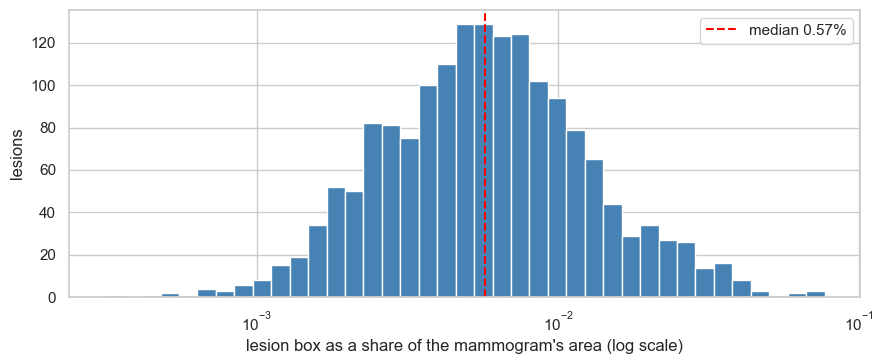

Lesions whose box is under 1 % of the mammogram: 77.1%

Input side 224 px, crop margin 0.2
Mammogram pixels per input pixel, whole image: median 23.6
Mammogram pixels per input pixel, crop: median 2.0
Input pixels spanned by the mass in its crop: median 160


In [7]:
size_cols = ["box_h", "box_w", "aspect", "box_area_frac"]
percentiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
display(geom[size_cols].describe(percentiles=percentiles).round(4))

share = geom["box_area_frac"]
fig, ax = plt.subplots(figsize=(9, 3.8))
log_bins = np.logspace(np.log10(share.min()), np.log10(share.max()), 40)
ax.hist(share, bins=log_bins, color="steelblue")
ax.axvline(share.median(), color="red", linestyle="--", label=f"median {share.median():.2%}")
ax.set_xscale("log")
ax.set_xlabel("lesion box as a share of the mammogram's area (log scale)")
ax.set_ylabel("lesions")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "box_share_of_mammogram.png")
plt.show()

print(f"Lesions whose box is under 1 % of the mammogram: {(share < 0.01).mean():.1%}")

MARGIN = config.CROP_MARGIN_FRAC
side = config.TARGET_SIZE[0]
crop_h = geom["box_h"] + 2 * (geom["box_h"] * MARGIN).astype(int)
crop_w = geom["box_w"] + 2 * (geom["box_w"] * MARGIN).astype(int)
whole_reduction = np.maximum(geom["img_h"], geom["img_w"]) / side
crop_reduction = np.maximum(crop_h, crop_w) / side
lesion_span = side * geom["box_h"] / crop_h

print(f"\nInput side {side} px, crop margin {MARGIN}")
print(f"Mammogram pixels per input pixel, whole image: median {whole_reduction.median():.1f}")
print(f"Mammogram pixels per input pixel, crop: median {crop_reduction.median():.1f}")
print(f"Input pixels spanned by the mass in its crop: median {lesion_span.median():.0f}")

### 5.2 Foreground share and the loss

A segmentation network labels every pixel as lesion or background. The cell gives the lesion pixels as a share of the whole mammogram, and as a share of the lesion's own box.

With so little foreground, a network can reach a very low pixel-wise error by predicting background everywhere. The localiser's loss therefore adds a soft Dice term to the binary cross-entropy. Dice measures the overlap between the predicted and the true foreground, so it cannot be satisfied by ignoring the lesion.

In [8]:
of_image, of_box = geom["fg_frac_of_mask"], geom["fg_frac_of_box"]
high = of_image.quantile(0.95)
print(f"Lesion pixels as a share of the mammogram: median {of_image.median():.3%}")
print(f"Lesion pixels as a share of the mammogram: 95th percentile {high:.3%}")
print(f"Lesion pixels as a share of the lesion box: median {of_box.median():.1%}")

Lesion pixels as a share of the mammogram: median 0.358%
Lesion pixels as a share of the mammogram: 95th percentile 1.478%
Lesion pixels as a share of the lesion box: median 63.7%


## 6. Input size for the localiser

The localiser takes the whole mammogram, reduced to a fixed input. The reduction has to keep the smallest masses large enough to segment. Each halving of resolution inside a network halves the lesion too, so after four halvings a mass 32 pixels across is 2 pixels across, and one 16 pixels across is a single pixel.

The table compares three ways of fitting a mammogram into an input, at several sizes.

- **Pad to a square.** The image is padded to a square and resized. This is what the whole-image classifier does. Mammograms are tall, so much of the square is padding.
- **Stretch.** The image is resized to the input on each axis separately, which distorts the shape of the mass.
- **Letterbox.** The image is resized by one factor to fit inside a tall input and the remainder is padded. The shape is kept and little of the input is padding.

For each scheme the table gives the size of the input, the smaller side of the median lesion box once reduced, the share of lesions left under 32 and under 16 pixels, the distortion (height scale over width scale) and the share of the input that is padding. The scheme the project uses is marked in the figure.

,input pixels (millions),median smaller side (px),share under 32 px,share under 16 px,distortion,share of input that is padding
scheme,,,,,,
"pad to square, 512 x 512",0.262,27.587,0.649,0.078,1.0,0.400
"pad to square, 768 x 768",0.590,41.381,0.252,0.008,1.0,0.400
"pad to square, 1024 x 1024",1.049,55.174,0.078,0.003,1.0,0.400
"stretch, 512 x 512",0.262,29.555,0.581,0.058,0.6,0.000
"letterbox, 896 x 512",0.459,45.324,0.203,0.008,1.0,0.102
"letterbox, 1024 x 576",0.590,51.126,0.134,0.006,1.0,0.108
"letterbox, 1280 x 704",0.901,62.769,0.044,0.003,1.0,0.119


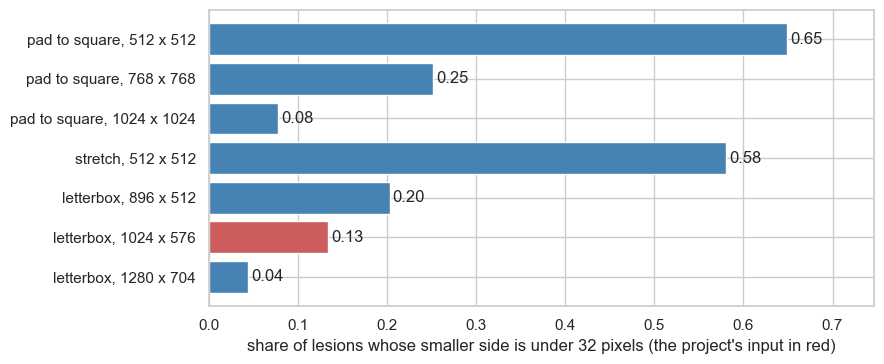

In [9]:
SCHEMES = {
    "pad to square, 512 x 512": ("pad", 512, 512),
    "pad to square, 768 x 768": ("pad", 768, 768),
    "pad to square, 1024 x 1024": ("pad", 1024, 1024),
    "stretch, 512 x 512": ("stretch", 512, 512),
    "letterbox, 896 x 512": ("letterbox", 896, 512),
    "letterbox, 1024 x 576": ("letterbox", 1024, 576),
    "letterbox, 1280 x 704": ("letterbox", 1280, 704),
}
CHOSEN = f"letterbox, {CANVAS_H} x {CANVAS_W}"
assert CHOSEN in SCHEMES, "The canvas in config is not among the schemes compared"


def scheme_scales(mode: str, out_h: int, out_w: int) -> tuple[pd.Series, pd.Series]:
    h, w = geom["img_h"], geom["img_w"]
    if mode == "stretch":
        return out_h / h, out_w / w
    if mode == "pad":
        scale = out_h / np.maximum(h, w)
    else:
        scale = np.minimum(out_h / h, out_w / w)
    return scale, scale


rows = []
for name, (mode, out_h, out_w) in SCHEMES.items():
    sy, sx = scheme_scales(mode, out_h, out_w)
    smaller_side = np.minimum(geom["box_h"] * sy, geom["box_w"] * sx)
    content = (geom["img_h"] * sy) * (geom["img_w"] * sx) / (out_h * out_w)
    rows.append(
        {
            "scheme": name,
            "input pixels (millions)": out_h * out_w / 1e6,
            "median smaller side (px)": smaller_side.median(),
            "share under 32 px": (smaller_side < 32).mean(),
            "share under 16 px": (smaller_side < 16).mean(),
            "distortion": (sy / sx).median(),
            "share of input that is padding": 1 - content.median(),
        }
    )
schemes = pd.DataFrame(rows).set_index("scheme")
display(schemes.round(3))

colours = ["indianred" if name == CHOSEN else "steelblue" for name in schemes.index]
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.barh(schemes.index, schemes["share under 32 px"], color=colours)
ax.bar_label(ax.containers[0], fmt="%.2f", padding=2)
ax.invert_yaxis()
ax.set_xlim(0, schemes["share under 32 px"].max() * 1.15)
ax.set_xlabel("share of lesions whose smaller side is under 32 pixels (the project's input in red)")
fig.tight_layout()
fig.savefig(FIG_DIR / "input_schemes.png")
plt.show()

## 7. Boxes on the canvas

### 7.1 Round trip

The localiser predicts on the letterboxed canvas, and its box is carried back to the mammogram before anything is cropped. Any error in that transform would shift every crop. The cell takes each full-resolution box from section 3, maps it to the canvas with `Letterbox.forward_box`, maps it back with `inverse_box`, and compares the result with the original.

A perfect return is not possible, because one canvas pixel covers several mammogram pixels and box edges are rounded to whole pixels. The test is therefore a bound: no edge may move by more than one canvas pixel's worth of mammogram pixels, plus two for the two roundings. The table also gives the overlap of the returned box with the original, by lesion size, for the tight box and for the box expanded by the crop margin in `config`.

In [10]:
def round_trip(row) -> dict:
    shape = (int(row.img_h), int(row.img_w))
    box_h, box_w = int(row.box_h), int(row.box_w)
    letterbox = Letterbox.for_shape(*shape)

    truth = (int(row.box_y0), int(row.box_y1), int(row.box_x0), int(row.box_x1))

    on_canvas = letterbox.forward_box(truth)
    back = letterbox.inverse_box(on_canvas)
    inside_h = 0 <= on_canvas[0] <= on_canvas[1] < letterbox.out_h
    inside_w = 0 <= on_canvas[2] <= on_canvas[3] < letterbox.out_w
    content = letterbox.content_h * letterbox.content_w
    return {
        "scale": letterbox.scale,
        "iou": box_iou(truth, back),
        "iou at margin": box_iou(expand_box(truth, MARGIN, shape), expand_box(back, MARGIN, shape)),
        "largest edge error (px)": max(abs(a - b) for a, b in zip(truth, back)),
        "smaller side (px)": min(box_h, box_w),
        "canvas box height": on_canvas[1] - on_canvas[0] + 1,
        "canvas box width": on_canvas[3] - on_canvas[2] + 1,
        "padding": 1 - content / (letterbox.out_h * letterbox.out_w),
        "inside canvas": inside_h and inside_w,
    }


trip = pd.DataFrame([round_trip(row) for row in geom.itertuples()])
trip["bound (px)"] = np.ceil(1.0 / trip["scale"]) + 2
over_bound = int((trip["largest edge error (px)"] > trip["bound (px)"]).sum())
on_canvas_side = np.minimum(trip["canvas box height"], trip["canvas box width"])

print(f"Canvas: {CANVAS_H} x {CANVAS_W} | margin {MARGIN:.0%}")
print(f"Mammogram pixels per canvas pixel: median {(1 / trip['scale']).median():.1f}")
print(f"Padding on the canvas: median {trip['padding'].median():.1%}")
canvas_h, canvas_w = trip["canvas box height"].median(), trip["canvas box width"].median()
print(f"Lesion on the canvas: median {canvas_h:.0f} px high, {canvas_w:.0f} px wide")
for limit in (32, 16):
    under = on_canvas_side < limit
    print(f"Lesions under {limit} px on the canvas: {int(under.sum())} ({under.mean():.1%})")
print(f"Boxes inside the canvas: {int(trip['inside canvas'].sum())} of {len(trip)}")
print(f"Boxes whose edges return within the bound: {len(trip) - over_bound} of {len(trip)}")

trip["lesion size band (px)"] = pd.qcut(trip["smaller side (px)"], 5, precision=0)
by_size = trip.groupby("lesion size band (px)", observed=True).agg(
    lesions=("iou", "size"),
    median_iou=("iou", "median"),
    lowest_iou=("iou", "min"),
    median_iou_at_margin=("iou at margin", "median"),
)
display(by_size.round(4))

assert trip["inside canvas"].all(), "A box falls outside the canvas"
assert over_bound == 0, "An edge moved by more than the rounding bound: the transform is wrong"
assert trip["iou"].median() > 0.98, "Median round-trip IoU is below 0.98"

Canvas: 1024 x 576 | margin 20%
Mammogram pixels per canvas pixel: median 5.4
Padding on the canvas: median 10.8%
Lesion on the canvas: median 56 px high, 56 px wide
Lesions under 32 px on the canvas: 190 (11.2%)
Lesions under 16 px on the canvas: 6 (0.4%)
Boxes inside the canvas: 1696 of 1696
Boxes whose edges return within the bound: 1696 of 1696


,lesions,median_iou,lowest_iou,median_iou_at_margin
lesion size band (px),,,,
"(54.0, 211.0]",343,0.9707,0.9211,0.9748
"(211.0, 257.0]",339,0.9794,0.9558,0.9822
"(257.0, 307.0]",340,0.9817,0.9613,0.9841
"(307.0, 380.0]",338,0.9851,0.9610,0.9869
"(380.0, 1329.0]",336,0.9899,0.9692,0.9914


### 7.2 The pipeline's canvas-derived boxes

The ladder's ground-truth conditions do not crop from the boxes of section 3. For the localiser, each mask is letterboxed onto the canvas and thresholded again (`src/precompute_localiser.py`). `src/localise_eval.py` takes the bounding box of the foreground on the canvas, maps it back to the mammogram and stores it in `artifacts/localiser_boxes_*.csv`, and `src/boxes.py` serves those boxes as ground truth. The ground-truth box and the localiser's predicted box therefore live on the same grid, which is what a fair comparison of the two needs. The cost is resolution: the mask is resampled onto the canvas and thresholded again, and the box is rounded on the way back, so an edge can move by up to about three canvas pixels.

The cell compares the two sets of boxes on the training and validation partitions: how many are identical, their overlap, and the largest difference in any edge. It sets that difference against the width of the crop margin, which is what decides whether it matters to a crop.

In [11]:
rows = []
for part in ("train", "val"):
    stored = pd.read_csv(ARTIFACTS / f"localiser_boxes_{part}.csv")
    stored = stored[["lesion_id", "gt_y0", "gt_y1", "gt_x0", "gt_x1"]].dropna()
    both = geom.merge(stored, on="lesion_id")

    top = np.maximum(both["box_y0"], both["gt_y0"])
    left = np.maximum(both["box_x0"], both["gt_x0"])
    bottom = np.minimum(both["box_y1"], both["gt_y1"])
    right = np.minimum(both["box_x1"], both["gt_x1"])
    inter = (bottom - top + 1).clip(lower=0) * (right - left + 1).clip(lower=0)
    area_full = both["box_h"] * both["box_w"]
    area_canvas = (both["gt_y1"] - both["gt_y0"] + 1) * (both["gt_x1"] - both["gt_x0"] + 1)
    iou = inter / (area_full + area_canvas - inter)

    corners = (("box_y0", "gt_y0"), ("box_y1", "gt_y1"), ("box_x0", "gt_x0"), ("box_x1", "gt_x1"))
    edge = pd.concat([(both[a] - both[b]).abs() for a, b in corners], axis=1).max(axis=1)
    margin_px = (np.minimum(both["box_h"], both["box_w"]) * MARGIN).astype(int)
    rows.append(
        {
            "partition": part,
            "lesions": len(both),
            "identical boxes": int((edge == 0).sum()),
            "median IoU": iou.median(),
            "lowest IoU": iou.min(),
            "median edge difference (px)": edge.median(),
            "largest edge difference (px)": edge.max(),
            "median crop margin (px)": margin_px.median(),
        }
    )
canvas_boxes = pd.DataFrame(rows).set_index("partition")
display(canvas_boxes.round(4))

,lesions,identical boxes,median IoU,lowest IoU,median edge difference (px),largest edge difference (px),median crop margin (px)
partition,,,,,,,
train,1210,0,0.9485,0.7847,7.0,14,57.0
val,243,0,0.9426,0.6910,7.0,17,54.0


## 8. Crop margin

The classifier's crop is the lesion box expanded by a margin, so that the network sees the tissue around the mass as well as the mass. The margin is a fraction of the box side and is added on every side (`expand_box` in `src/localise.py`, and the same arithmetic in `data_loader`). Near the edge of the image the expanded box runs past the border and has to be clamped, which moves the mass away from the centre of the crop and shrinks the context on one side. The larger the margin, the more often this happens.

The cell computes, for a range of margins, the share of lesions whose crop is clamped and the share of the mammogram a crop covers. It first checks its arithmetic twice: against the margins the cached table already holds, and against `expand_box` itself at the margin in `config`.

An early sweep of the single-crop classifier covered the margins of the cached table, from 0 to 1.00. The sweep the project relies on compared the margins 0.10, 0.20, 0.30 and 0.40 and left out the two largest, because of the share of their crops that would be clamped. The value held in `config`, marked by the vertical line, was tested against the other small margins on validation results and stands because none of them displaced it; this figure played no part. The context-fusion model is a separate case: its second stream uses the largest margin on purpose, as a wide view of the surrounding tissue.

The rebuilt boxes reproduce the cached table at every cached margin.
The same arithmetic as expand_box, checked on every lesion at margin 0.2.


,share of crops clamped,median share of the mammogram in the crop
margin,,
0.0,0.0000,0.0057
0.1,0.0413,0.0082
0.2,0.0578,0.0111
0.3,0.0879,0.0145
0.4,0.1126,0.0183
0.8,0.2093,0.0370
1.0,0.2577,0.0487


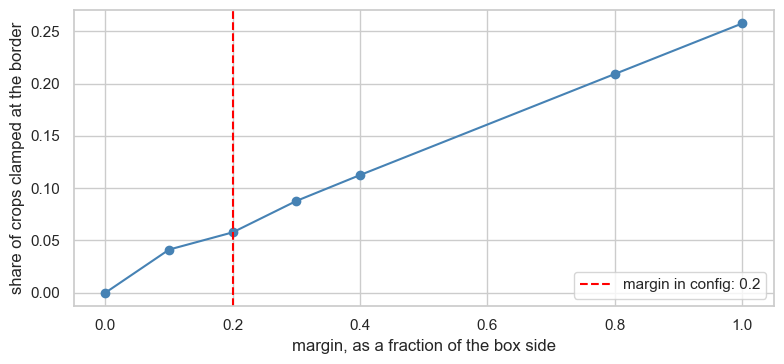

In [12]:
MARGINS = (0.0, 0.10, 0.20, 0.30, 0.40, 0.80, 1.00)


def crop_pixels(margin: float) -> tuple[pd.Series, pd.Series]:
    my = (geom["box_h"] * margin).astype(int)
    mx = (geom["box_w"] * margin).astype(int)
    top = (geom["box_y0"] - my).clip(lower=0)
    left = (geom["box_x0"] - mx).clip(lower=0)
    bottom = np.minimum(geom["box_y1"] + 1 + my, geom["img_h"])
    right = np.minimum(geom["box_x1"] + 1 + mx, geom["img_w"])
    wanted = (geom["box_h"] + 2 * my) * (geom["box_w"] + 2 * mx)
    kept = (bottom - top) * (right - left)
    return kept, wanted


def crop_at(margin: float) -> tuple[pd.Series, pd.Series]:
    kept, wanted = crop_pixels(margin)
    return kept < wanted, kept / (geom["img_h"] * geom["img_w"])


for margin in CACHED_MARGINS:
    clamped, _ = crop_at(margin)
    cached = geom[f"m{int(margin * 100):03d}_clamped"]
    assert (clamped == cached).all(), f"Margin {margin}: rebuilt boxes differ from the cached table"
print("The rebuilt boxes reproduce the cached table at every cached margin.")

kept, _ = crop_pixels(MARGIN)
for row, pixels in zip(geom.itertuples(), kept):
    box = (int(row.box_y0), int(row.box_y1), int(row.box_x0), int(row.box_x1))
    y0, y1, x0, x1 = expand_box(box, MARGIN, (int(row.img_h), int(row.img_w)))
    assert (y1 - y0 + 1) * (x1 - x0 + 1) == pixels, "The arithmetic here differs from expand_box"
print(f"The same arithmetic as expand_box, checked on every lesion at margin {MARGIN}.")

rows = []
for margin in MARGINS:
    clamped, covered = crop_at(margin)
    rows.append(
        {
            "margin": margin,
            "share of crops clamped": clamped.mean(),
            "median share of the mammogram in the crop": covered.median(),
        }
    )
margins = pd.DataFrame(rows).set_index("margin")
display(margins.round(4))

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(margins.index, margins["share of crops clamped"], marker="o", color="steelblue")
ax.axvline(MARGIN, color="red", linestyle="--", label=f"margin in config: {MARGIN}")
ax.set_xlabel("margin, as a fraction of the box side")
ax.set_ylabel("share of crops clamped at the border")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "margin_clamping.png")
plt.show()

## 9. Summary

The table is built from the values computed above, so it cannot disagree with them.

In [13]:
def joined(values, spec: str = "") -> str:
    return " / ".join(format(value, spec) for value in values)


chosen = schemes.loc[CHOSEN]
pad_square_512 = schemes.loc["pad to square, 512 x 512"]
several_train = several.loc["Train", "mammograms with several lesions"]
different_grid = int((~geom["grid_exact"]).sum())
edge_cases = int((on_canvas_side < 16).sum())

summary = {
    "Patients / mammograms / lesions": joined(
        (pool["patient_id"].nunique(), pool["image_id"].nunique(), len(pool)), ","
    ),
    "Lesions, train / validation / test": joined((recorded[p]["lesions"] for p in PARTS), ","),
    "Training mammograms with several lesions": str(several_train),
    "Masks stored at a different size from their mammogram": str(different_grid),
    "Lowest IoU between the box of all foreground and of the largest component": format(
        components["box_iou"].min(), ".4f"
    ),
    "Lesion box, median height x width (mammogram px)": (
        f"{geom['box_h'].median():.0f} x {geom['box_w'].median():.0f}"
    ),
    "Lesion box as a share of the mammogram, median": format(geom["box_area_frac"].median(), ".2%"),
    "Lesion pixels as a share of the mammogram, median": format(
        geom["fg_frac_of_mask"].median(), ".2%"
    ),
    f"Lesions under 32 px, pad to square 512 / {CHOSEN}": joined(
        (pad_square_512["share under 32 px"], chosen["share under 32 px"]), ".1%"
    ),
    f"Padding, pad to square 512 / {CHOSEN}": joined(
        (
            pad_square_512["share of input that is padding"],
            chosen["share of input that is padding"],
        ),
        ".1%",
    ),
    "Lesions under 16 px on the canvas": str(edge_cases),
    "Round trip: median IoU, tight box / at the crop margin": joined(
        (trip["iou"].median(), trip["iou at margin"].median()), ".4f"
    ),
    "Round trip: boxes beyond the rounding bound": str(over_bound),
    "Canvas-derived against full-resolution boxes, median IoU, train / validation": joined(
        canvas_boxes["median IoU"], ".4f"
    ),
    f"Input pixels spanned by the mass in its crop at margin {MARGIN}, median": format(
        lesion_span.median(), ".0f"
    ),
    "Crops clamped at margins " + joined(MARGINS): joined(margins["share of crops clamped"], ".1%"),
}

table = "\n".join(f"| {name} | {value} |" for name, value in summary.items())
display(Markdown("| property | value |\n| :--- | :--- |\n" + table))

| property | value |
| :--- | :--- |
| Patients / mammograms / lesions | 892 / 1,592 / 1,696 |
| Lesions, train / validation / test | 1,210 / 243 / 243 |
| Training mammograms with several lesions | 46 |
| Masks stored at a different size from their mammogram | 78 |
| Lowest IoU between the box of all foreground and of the largest component | 0.9638 |
| Lesion box, median height x width (mammogram px) | 302 x 304 |
| Lesion box as a share of the mammogram, median | 0.57% |
| Lesion pixels as a share of the mammogram, median | 0.36% |
| Lesions under 32 px, pad to square 512 / letterbox, 1024 x 576 | 64.9% / 13.4% |
| Padding, pad to square 512 / letterbox, 1024 x 576 | 40.0% / 10.8% |
| Lesions under 16 px on the canvas | 6 |
| Round trip: median IoU, tight box / at the crop margin | 0.9824 / 0.9851 |
| Round trip: boxes beyond the rounding bound | 0 |
| Canvas-derived against full-resolution boxes, median IoU, train / validation | 0.9485 / 0.9426 |
| Input pixels spanned by the mass in its crop at margin 0.2, median | 160 |
| Crops clamped at margins 0.0 / 0.1 / 0.2 / 0.3 / 0.4 / 0.8 / 1.0 | 0.0% / 4.1% / 5.8% / 8.8% / 11.3% / 20.9% / 25.8% |

### What this fixed in the design

1. **The lesion is the unit.** The crop classifiers are trained and evaluated on one crop per lesion. The whole-image model takes one mammogram per row instead. Six of the seven members of the localiser ensemble are trained on targets that merge all the masks of a mammogram (section 1).
2. **The ground-truth box is the bounding box of the thresholded mask.** The masks contain specks. For some lesions they change the box, but never by much, so it matters little whether the box is taken from all the foreground or from the largest component (section 4).
3. **The mass has to be found before it is classified.** It is a small share of the mammogram, and it keeps far more of its detail in a crop than in the whole image (section 5.1).
4. **The localiser's loss pairs cross-entropy with soft Dice,** because the foreground is a small fraction of the pixels (section 5.2).
5. **The localiser's input is a letterboxed canvas.** Among the inputs compared it keeps the shape of the mass, wastes little of the input on padding, and leaves few lesions under 32 pixels for its size (section 6).
6. **Boxes can be carried between the canvas and the mammogram safely.** Every box returns within the rounding bound (section 7.1).
7. **Ground-truth and predicted boxes are compared on the canvas grid.** The ladder's ground-truth boxes are derived on the canvas, so they differ slightly from the full-resolution boxes, by less than the crop margin (section 7.2).
8. **For the single-crop classifier, the two largest margins are left out of the sweep,** because of the share of crops they clamp at the image border. Among the small margins, the value in `config` stands on the validation results because none displaced it (section 8).

### Limits

- Sizes are in pixels. The files carry no pixel spacing (`01_eda`, section 11), so no size here is in millimetres.
- A crop is stretched to a square input, so masses whose boxes are far from square reach the classifier distorted (section 5.1).
- The geometry describes the radiologists' outlines as they were digitised. It says nothing about how well a network can find them; that is a question for the localiser's results.